# Module 5 Assignment Analysis
Anjali Khatri <br>
INST414 <br>
8/21/2026 <br>

In [13]:
# module  imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from io import BytesIO

from scipy.sparse import lil_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [4]:
#read in data
df = pd.read_csv("daily_aqi_by_county_2026.csv")
print("Rows and columns:", df.shape)
df.head()

Rows and columns: (77795, 10)


,State Name,county Name,State Code,County Code,Date,AQI,Category,Defining Parameter,Defining Site,Number of Sites Reporting
0,Alabama,Baldwin,1,3,2026-01-01,65,Moderate,PM2.5,01-003-0010,1
1,Alabama,Baldwin,1,3,2026-01-02,25,Good,PM2.5,01-003-0010,1
2,Alabama,Baldwin,1,3,2026-01-03,40,Good,PM2.5,01-003-0010,1
3,Alabama,Baldwin,1,3,2026-01-04,39,Good,PM2.5,01-003-0010,1
4,Alabama,Baldwin,1,3,2026-01-05,41,Good,PM2.5,01-003-0010,1


In [5]:
# data
print(df.columns.tolist())
print(df.isna().sum())

df[[
    "Date",
    "State Name",
    "county Name",
    "AQI",
    "Category",
    "Defining Parameter",
    "Number of Sites Reporting"
]].head()

['State Name', 'county Name', 'State Code', 'County Code', 'Date', 'AQI', 'Category', 'Defining Parameter', 'Defining Site', 'Number of Sites Reporting']
State Name                   0
county Name                  0
State Code                   0
County Code                  0
Date                         0
AQI                          0
Category                     0
Defining Parameter           0
Defining Site                0
Number of Sites Reporting    0
dtype: int64


,Date,State Name,county Name,AQI,Category,Defining Parameter,Number of Sites Reporting
0,2026-01-01,Alabama,Baldwin,65,Moderate,PM2.5,1
1,2026-01-02,Alabama,Baldwin,25,Good,PM2.5,1
2,2026-01-03,Alabama,Baldwin,40,Good,PM2.5,1
3,2026-01-04,Alabama,Baldwin,39,Good,PM2.5,1
4,2026-01-05,Alabama,Baldwin,41,Good,PM2.5,1


In [9]:
# review missing values

print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False))

df[
    [
        "Date",
        "State Name",
        "county Name",
        "AQI",
        "Category",
        "Defining Parameter",
        "Number of Sites Reporting"
    ]
].head()

Columns:
['State Name', 'county Name', 'State Code', 'County Code', 'Date', 'AQI', 'Category', 'Defining Parameter', 'Defining Site', 'Number of Sites Reporting', 'unhealthy_day', 'month', 'day_of_year']

Missing values:
State Name                   0
county Name                  0
State Code                   0
County Code                  0
Date                         0
AQI                          0
Category                     0
Defining Parameter           0
Defining Site                0
Number of Sites Reporting    0
unhealthy_day                0
month                        0
day_of_year                  0
dtype: int64


,Date,State Name,county Name,AQI,Category,Defining Parameter,Number of Sites Reporting
0,2026-01-01,Alabama,Baldwin,65,Moderate,PM2.5,1
1,2026-01-02,Alabama,Baldwin,25,Good,PM2.5,1
2,2026-01-03,Alabama,Baldwin,40,Good,PM2.5,1
3,2026-01-04,Alabama,Baldwin,39,Good,PM2.5,1
4,2026-01-05,Alabama,Baldwin,41,Good,PM2.5,1


In [10]:
# clean data
# Unhealthy day: AQI >= 101
# 0 = Good or Moderate
# 1 = Unhealthy for Sensitive Groups or worse


df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df = df.dropna(subset=["Date", "AQI"]).copy()

df["unhealthy_day"] = (df["AQI"] >= 101).astype(int)

df["month"] = df["Date"].dt.month
df["day_of_year"] = df["Date"].dt.dayofyear

df["Defining Parameter"] = (
    df["Defining Parameter"]
    .fillna("Unknown")
    .astype(str)
    .str.strip()
)

df["Number of Sites Reporting"] = (
    df["Number of Sites Reporting"]
    .fillna(df["Number of Sites Reporting"].median())
)

print(df["unhealthy_day"].value_counts())

unhealthy_day
0    77480
1      315
Name: count, dtype: int64


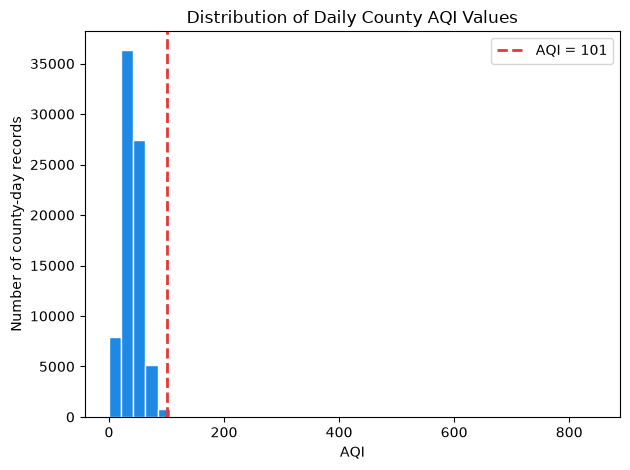

In [ ]:
# AQI distribution

plt.hist(
    df["AQI"],
    bins=40,
    color="#1E88E5",
    edgecolor="white"
)

plt.axvline(
    101,
    color="#E53935",
    linestyle="--",
    linewidth=2,
    label="AQI = 101"
)

plt.title("Distribution of Daily County AQI Values")
plt.xlabel("AQI")
plt.ylabel("Number of county-day records")
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
# Clustering

numeric_features = [
    "AQI",
    "month",
    "Number of Sites Reporting"
]

categorical_features = [
    "Defining Parameter"
]

feature_columns = numeric_features + categorical_features

feature_df = df[feature_columns].copy()

feature_df.head()

,AQI,month,Number of Sites Reporting,Defining Parameter
0,65,1,1,PM2.5
1,25,1,1,PM2.5
2,40,1,1,PM2.5
3,39,1,1,PM2.5
4,41,1,1,PM2.5


In [17]:
#feeature matrix
feature_transformer = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        (
            "pollutant",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features
        )
    ]
)

feature_matrix = feature_transformer.fit_transform(feature_df)

print("Feature matrix shape:", feature_matrix.shape)

Feature matrix shape: (77795, 8)
